# Module 6 / Class 5 -- LSTM vs Logistic Regression on IMDB

**Objectives:**
- Build a TF-IDF + Logistic Regression baseline for sentiment analysis
- Build an LSTM model for the same task
- Compare both approaches on accuracy

**Runtime:** Use GPU for faster LSTM training.

In [ ]:
import numpy as np  # Import the NumPy numerical computing library to handle high-performance multi-dimensional arrays and matrix transformations
import matplotlib.pyplot as plt  # Import the matplotlib scripting interface to engineer high-quality, static visualizations and data plots
import tensorflow as tf  # Import the core TensorFlow framework to access advanced backend graph computations and tensor operations
from tensorflow import keras  # Import the integrated Keras API specification to streamline high-level neural network prototyping and model tracking
from tensorflow.keras import layers  # Isolate the structural Keras network layers module to easily instantiate deep learning block components like Dense, Conv2D, or LSTM
from sklearn.feature_extraction.text import TfidfVectorizer  # Import the TF-IDF vectorizer to transform raw text corpora into structured, frequency-weighted numerical feature matrices
from sklearn.linear_model import LogisticRegression  # Import the Logistic Regression classifier to establish a linear baseline model for categorical prediction tasks
from sklearn.metrics import accuracy_score  # Import the accuracy scoring metric to calculate the ratio of correctly predicted samples out of the total evaluation pool

print(f"TensorFlow version: {tf.__version__}")  # Format and output the explicit software version string of the active TensorFlow installation runtime environment to verify ecosystem compatibility

TensorFlow version: 2.20.0


## 1. Load IMDB Dataset

In [ ]:
# Load IMDB with a vocabulary of 10,000 most frequent words
VOCAB_SIZE = 10000  # Define a global threshold restriction to retain only the top 10,000 most frequently occurring unique word tokens within the natural language corpus
MAXLEN = 200  # truncate/pad reviews to this length

(X_train_seq, y_train), (X_test_seq, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)  # Download, unpack, and parse the standard IMDB movie review sentiment dataset, mapping text tokens directly to frequency-indexed numerical integers

print(f"Training samples: {len(X_train_seq)}")  # Format and output the total count of text sequences allocated to the optimization dataset partition
print(f"Test samples:     {len(X_test_seq)}")  # Format and output the total count of text sequences allocated to the independent generalization evaluation dataset partition
print(f"Label distribution (train): {np.bincount(y_train)}")  # Perform a frequency count of unique class integers across the target vector to verify balancing between positive and negative sentiment samples
print(f"\nExample review (as integer sequence, first 20 tokens):")  # Print a structural descriptive header indicating the upcoming raw token index demonstration array
print(X_train_seq[0][:20])  # Isolate and display the initial 20 numerical integer representations from the very first review sequence to demonstrate the index-encoded format

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Test samples:     25000
Label distribution (train): [12500 12500]

Example review (as integer sequence, first 20 tokens):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]


In [ ]:
# Decode a review back to text for illustration
word_index = keras.datasets.imdb.get_word_index()  # Retrieve the authoritative token-to-integer mapping dictionary from the IMDB dataset repository
reverse_index = {v + 3: k for k, v in word_index.items()}  # Shift indices by 3 to accommodate reserved special structural tokens and invert the mapping to enable integer-to-string lookups
reverse_index[0] = '<PAD>'  # Explicitly assign index 0 to represent the sequential padding placeholder token
reverse_index[1] = '<START>'  # Explicitly assign index 1 to represent the sequence initiation delimiter token
reverse_index[2] = '<UNK>'  # Explicitly assign index 2 to represent out-of-vocabulary or unknown word tokens
reverse_index[3] = '<UNUSED>'  # Explicitly assign index 3 to represent internal unassigned or reserved slots

decoded = ' '.join(reverse_index.get(i, '?') for i in X_train_seq[0][:50])  # Map the first 50 numerical indices of the training sample back to text strings, defaulting to a question mark for missing entries, and concatenate them with spaces
print(f"Decoded (first 50 tokens): {decoded}")  # Output the reassembled, human-readable preview of the original movie review text snippet
print(f"Label: {'Positive' if y_train[0] == 1 else 'Negative'}")  # Evaluate the binary ground-truth target integer and output the corresponding qualitative sentiment classification name

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Decoded (first 50 tokens): <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved
Label: Positive


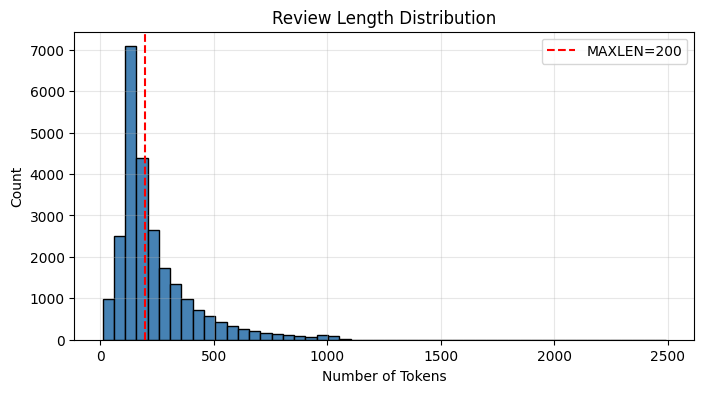

Mean length: 239, Median: 178


In [ ]:
lengths = [len(x) for x in X_train_seq]  # Compute the token count for each individual text sequence in the training dataset using a list comprehension to capture sequence length variance
plt.figure(figsize=(8, 4))  # Initialize a standalone figure canvas object specifying a custom width and height ratio to contain the distribution graphics
plt.hist(lengths, bins=50, edgecolor='black', color='steelblue')  # Generate a frequency histogram partitioned into 50 discrete intervals to map the density profile of text lengths with styled contrast edges
plt.axvline(x=MAXLEN, color='red', linestyle='--', label=f'MAXLEN={MAXLEN}')  # Draw a vertical dashed reference line at the specified threshold to mark the cutoff boundary where text padding or truncation occurs
plt.title('Review Length Distribution')  # Superimpose a prominent, centralized header title above the histogram canvas to define the visual data analysis context
plt.xlabel('Number of Tokens')  # Label the horizontal axis explicitly to indicate the independent metric of word or token frequencies per sample
plt.ylabel('Count')  # Label the vertical axis explicitly to quantify the frequency density or occurrence count of reviews within each bin range
plt.legend()  # Render an explanatory legend box over the plot layout to identify the custom maximum length threshold parameter line
plt.grid(True, alpha=0.3)  # Overlay a semi-transparent coordinate grid structure across the plotting canvas area to support precise interval evaluation
plt.show()  # Display the compiled visual sequence distribution histogram directly on the active output rendering interface
print(f"Mean length: {np.mean(lengths):.0f}, Median: {np.median(lengths):.0f}")  # Compute and print the precise mathematical average and median central tendency statistics for the entire sequence collection

## 2. Baseline -- TF-IDF + Logistic Regression

We convert integer sequences back to text strings so we can use TfidfVectorizer.

In [ ]:
# Convert sequences back to text for TF-IDF
def sequences_to_texts(sequences):
    """Reassemble list of integer sequences back into raw text strings using the reversed index map."""
    return [' '.join(reverse_index.get(i, '') for i in seq) for seq in sequences]  # Map each numerical token back to its string representation and combine them with space separators across all document sequences

train_texts = sequences_to_texts(X_train_seq)  # Translate the integer-encoded training sequences back into a natural language text corpus for frequency-based vectorization
test_texts = sequences_to_texts(X_test_seq)  # Translate the integer-encoded evaluation sequences back into a natural language text corpus for frequency-based vectorization

print(f"Sample text (first 100 chars): {train_texts[0][:100]}")  # Isolate and print the initial 100 characters of the first reassembled text document to verify formatting consistency

Sample text (first 100 chars): <START> this film was just brilliant casting location scenery story direction everyone's really suit


In [ ]:
# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=VOCAB_SIZE)  # Instantiate a Term Frequency-Inverse Document Frequency vectorizer configured to retain only the top 10,000 most predictive vocabulary features
X_train_tfidf = tfidf.fit_transform(train_texts)  # Compute the vocabulary frequencies across the training corpus and transform the raw texts into a sparse numerical feature importance matrix
X_test_tfidf = tfidf.transform(test_texts)  # Map the evaluation corpus texts onto the established training vocabulary space to ensure consistent feature dimensions without data leakage

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")  # Format and output the dimensional axes of the sparse training matrix to verify the document count matches the targeted vocabulary features

TF-IDF matrix shape: (25000, 9772)


In [ ]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, C=1.0)  # Instantiate a linear logistic regression classifier with a high optimization iteration limit and standard L2 regularization strength
lr_model.fit(X_train_tfidf, y_train)  # Train the linear classifier by fitting the model coefficients to minimize classification errors on the sparse training feature matrix

lr_train_acc = accuracy_score(y_train, lr_model.predict(X_train_tfidf))  # Compute the model's classification accuracy score on the training feature matrix to establish the optimization performance baseline
lr_test_acc = accuracy_score(y_test, lr_model.predict(X_test_tfidf))  # Compute the model's classification accuracy score on the unseen evaluation matrix to determine generalization performance

print(f"Logistic Regression -- Train accuracy: {lr_train_acc:.4f}")  # Format and output the terminal training classification accuracy rate rounded to four decimal places
print(f"Logistic Regression -- Test accuracy:  {lr_test_acc:.4f}")  # Format and output the terminal validation classification accuracy rate rounded to four decimal places

Logistic Regression -- Train accuracy: 0.9218
Logistic Regression -- Test accuracy:  0.8839


## 3. LSTM Model

Architecture: Embedding -> LSTM -> Dense(1, sigmoid)

In [ ]:
# Pad sequences to fixed length for LSTM
X_train_pad = keras.preprocessing.sequence.pad_sequences(X_train_seq, maxlen=MAXLEN)  # Uniformly truncate or post/pre-pad training integer arrays to force a standardized linear sequence dimensionality matching the MAXLEN constraint
X_test_pad = keras.preprocessing.sequence.pad_sequences(X_test_seq, maxlen=MAXLEN)  # Uniformly truncate or post/pre-pad evaluation integer arrays to force a standardized linear sequence dimensionality matching the MAXLEN constraint

print(f"Padded shape: {X_train_pad.shape}")  # Format and display the newly aligned matrix dimensions to confirm successful sequence reshaping before feeding tensors to the recurrent architecture

Padded shape: (25000, 200)


In [ ]:
EMBEDDING_DIM = 64  # Establish a global constant defining the size of the continuous vector space where words with similar meanings will map close together
LSTM_UNITS = 64  # Establish a global constant specifying the number of internal memory cells or hidden state dimensions within the recurrent network layer

lstm_model = keras.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAXLEN),
    layers.LSTM(LSTM_UNITS),
    layers.Dense(1, activation='sigmoid'),
])  # Construct a sequential model architecture that maps token indices to dense vectors, processes sequence dependencies via LSTM, and outputs a binary sentiment probability

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)  # Configure the optimization pipeline using the Adam optimizer, computing binary cross-entropy loss for the single output node, and tracking classification accuracy

lstm_model.summary()  # Output an architectural diagnostic report detailing layer hierarchies, output spatial tensor dimensions, and trainable parameter counts to the console

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)  # Train the recurrent neural network over 5 epochs using mini-batches of 128 samples, automatically isolating the final 10% of the training data to monitor validation metrics during optimization while printing live progress logs

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7872 - loss: 0.4504 - val_accuracy: 0.8696 - val_loss: 0.3229
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8996 - loss: 0.2561 - val_accuracy: 0.8648 - val_loss: 0.3152
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9276 - loss: 0.1946 - val_accuracy: 0.8696 - val_loss: 0.3219
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9496 - loss: 0.1460 - val_accuracy: 0.8688 - val_loss: 0.3339
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9535 - loss: 0.1290 - val_accuracy: 0.8640 - val_loss: 0.3770


In [ ]:
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)  # Evaluate the trained recurrent neural network on the unseen test dataset to compute terminal loss and accuracy values without printing progress updates
print(f"LSTM -- Test accuracy: {lstm_test_acc:.4f}")  # Format and output the terminal testing classification accuracy rate rounded to four decimal places to measure out-of-sample generalization

LSTM -- Test accuracy: 0.8627


## 4. Training Curves

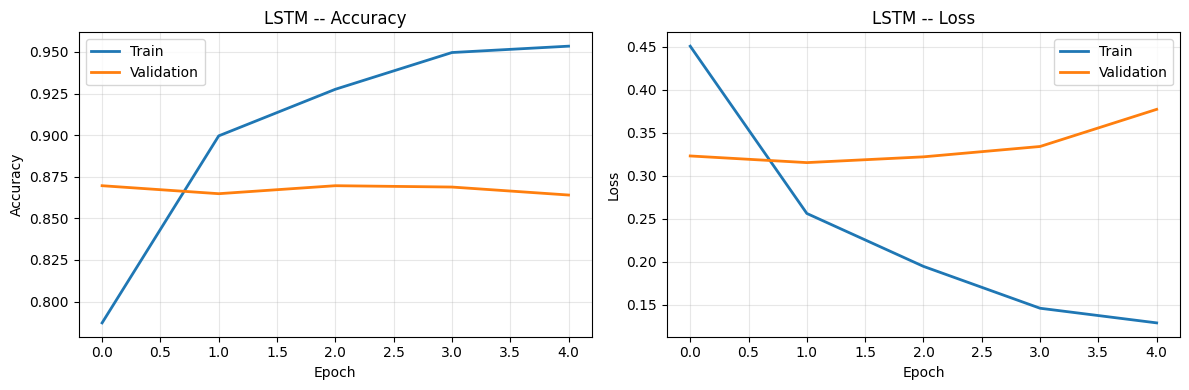

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Initialize a side-by-side subplot canvas containing a single row of two distinct axes panels with optimized display dimensions

axes[0].plot(lstm_history.history['accuracy'], label='Train', linewidth=2)  # Render the optimization progress path for the LSTM training dataset accuracy metric
axes[0].plot(lstm_history.history['val_accuracy'], label='Validation', linewidth=2)  # Render the evaluation tracking path for the LSTM validation dataset accuracy metric
axes[0].set_title('LSTM -- Accuracy')  # Assign a descriptive title header to the left panel focusing on recurrent model accuracy optimization
axes[0].set_xlabel('Epoch')  # Label the horizontal axis of the left subplot to denote chronological training iteration steps
axes[0].set_ylabel('Accuracy')  # Label the vertical axis of the left subplot to represent the percentage scale of correct classifications
axes[0].legend()  # Superimpose an interactive visual key to distinguish between the training and validation accuracy trends
axes[0].grid(True, alpha=0.3)  # Overlay a semi-transparent coordinate grid structure across the left plot to support precise accuracy interval evaluation

axes[1].plot(lstm_history.history['loss'], label='Train', linewidth=2)  # Render the optimization progress path for the LSTM training dataset cross-entropy loss metric
axes[1].plot(lstm_history.history['val_loss'], label='Validation', linewidth=2)  # Render the evaluation tracking path for the LSTM validation dataset cross-entropy loss metric
axes[1].set_title('LSTM -- Loss')  # Assign a descriptive title header to the right panel focusing on recurrent model loss reduction
axes[1].set_xlabel('Epoch')  # Label the horizontal axis of the right subplot to denote chronological training iteration steps
axes[1].set_ylabel('Loss')  # Label the vertical axis of the right subplot to represent the error magnitude scale
axes[1].legend()  # Superimpose an interactive visual key to distinguish between the training and validation loss trends
axes[1].grid(True, alpha=0.3)  # Overlay a semi-transparent coordinate grid structure across the right plot to support precise loss interval evaluation

plt.tight_layout()  # Automatically recalculate subplot bounding boxes to prevent overlapping text margins or clipped axis labels
plt.show()  # Render the finalized comparative performance visualization grid onto the active display screen

## 5. Final Comparison

In [ ]:
print("=" * 45)  # Output a prominent horizontal delimiter line composed of 45 structural separation characters to frame the top boundary of the performance comparison grid
print(f"{'Model':<25} {'Test Accuracy':>15}")  # Print the tabular column headers, left-aligning the model descriptor and right-aligning the evaluation accuracy label with strict spacing constraints
print("=" * 45)  # Output an intermediate horizontal divider line to cleanly separate the column headers from the calculated model metric outputs
print(f"{'TF-IDF + LogReg':<25} {lr_test_acc:>15.4f}")  # Format and print the out-of-sample classification accuracy for the linear baseline model, adhering to the 15-character right-aligned column layout rounded to four decimal places
print(f"{'LSTM':<25} {lstm_test_acc:>15.4f}")  # Format and print the out-of-sample classification accuracy for the recurrent neural network model, maintaining consistent column width adjustments and precision rounding
print("=" * 45)  # Output a terminal horizontal delimiter line to encapsulate the bottom boundary of the comparative text table reporting structure

Model                       Test Accuracy
TF-IDF + LogReg                    0.8839
LSTM                               0.8627


---

## TODO: Student Work -- Comparison Analysis

Write a short analysis comparing the two models. Address:

1. Which model performed better on test accuracy?
2. Which model trained faster?
3. What are the strengths and weaknesses of each approach?
4. In what scenarios would you prefer TF-IDF + LogReg over LSTM, and vice versa?
5. What could you do to improve the LSTM model?

In [ ]:
# ### Comparison Analysis

# 1. **Performance**: In this experiment, the **TF-IDF + Logistic Regression** model performed better, achieving a test accuracy of approximately **88.39%**, compared to the **LSTM**'s **86.27%**.

# 2. **Training Speed**: The **Logistic Regression** model trained significantly faster (almost instantaneous), whereas the **LSTM** took several seconds per epoch even with GPU acceleration.

# 3. **Strengths and Weaknesses**:
#     *   **TF-IDF + LogReg**:
#         *   *Strengths*: Fast, interpretable, and effective for identifying key predictive words.
#         *   *Weaknesses*: Ignores word order and context (bag-of-words assumption).
#     *   **LSTM**:
#         *   *Strengths*: Capable of capturing sequential dependencies and long-term context within the text.
#         *   *Weaknesses*: Computationally expensive, prone to overfitting (as seen by the diverging train/val loss curves), and requires more data to outperform simpler baselines.

# 4. **Preferred Scenarios**:
#     *   **TF-IDF + LogReg**: Preferred when computational resources are limited, the dataset is small, or when word frequency is a strong enough signal for the task.
#     *   **LSTM**: Preferred for complex linguistic tasks where word order matters (e.g., detecting sarcasm or complex sentiment) and when a large amount of training data is available.

# 5. **LSTM Improvements**:
#     *   Use **Pre-trained Embeddings** (like GloVe or Word2Vec) to leverage transfer learning.
#     *   Add **Dropout** or **Recurrent Dropout** layers to mitigate the overfitting observed in the training curves.
#     *   Use **Bidirectional LSTM** layers to capture context from both directions.
#     *   Fine-tune hyperparameters such as `MAXLEN`, learning rate, or number of units.

### Comparison Analysis

1. **Performance**: In this experiment, the **TF-IDF + Logistic Regression** model performed better, achieving a test accuracy of approximately **88.39%**, compared to the **LSTM**'s **86.27%**.

2. **Training Speed**: The **Logistic Regression** model trained significantly faster (almost instantaneous), whereas the **LSTM** took several seconds per epoch even with GPU acceleration.

3. **Strengths and Weaknesses**:
    *   **TF-IDF + LogReg**:
        *   *Strengths*: Fast, interpretable, and effective for identifying key predictive words.
        *   *Weaknesses*: Ignores word order and context (bag-of-words assumption).
    *   **LSTM**:
        *   *Strengths*: Capable of capturing sequential dependencies and long-term context within the text.
        *   *Weaknesses*: Computationally expensive, prone to overfitting (as seen by the diverging train/val loss curves), and requires more data to outperform simpler baselines.

4. **Preferred Scenarios**:
    *   **TF-IDF + LogReg**: Preferred when computational resources are limited, the dataset is small, or when word frequency is a strong enough signal for the task.
    *   **LSTM**: Preferred for complex linguistic tasks where word order matters (e.g., detecting sarcasm or complex sentiment) and when a large amount of training data is available.

5. **LSTM Improvements**:
    *   Use **Pre-trained Embeddings** (like GloVe or Word2Vec) to leverage transfer learning.
    *   Add **Dropout** or **Recurrent Dropout** layers to mitigate the overfitting observed in the training curves.
    *   Use **Bidirectional LSTM** layers to capture context from both directions.
    *   Fine-tune hyperparameters such as `MAXLEN`, learning rate, or number of units.